# Dataset Verification and Sample Visualization

This notebook verifies whether the configured datasets are available, summarizes the folder structure, counts normal/anomalous samples where possible, and visualizes RGB samples for each dataset.

Supported datasets:

- `MVtec`
- `Robotics_Hazards`
- `Distrimuse_UniGra`

The notebook supports absolute paths, symlinked folders, and environment-variable-based paths from `configs/config.yaml`.

In [1]:
# ============================================================
# 1. Imports and basic setup
# ============================================================
from pathlib import Path
import os
import re
import random
import yaml
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.figsize"] = (14, 6)
random.seed(42)

# Image extensions supported by the scanner
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

print("✓ Imports loaded")

✓ Imports loaded


## 2. Locate project root and load configuration

Run this notebook from inside the repository. If needed, manually set `PROJECT_ROOT` below.

In [2]:
# ============================================================
# 2. Project root and config loading
# ============================================================

def find_project_root(start=None):
    start = Path(start or os.getcwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "configs" / "config.yaml").exists():
            return p
    raise FileNotFoundError("Could not find configs/config.yaml. Please set PROJECT_ROOT manually.")

# If automatic detection fails, uncomment and edit this line:
# PROJECT_ROOT = Path(r"E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold")
PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CONFIG_PATH:", CONFIG_PATH)

PROJECT_ROOT: /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold
CONFIG_PATH: /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/configs/config.yaml


## 3. Resolve dataset paths

This cell supports:

- Absolute paths in `config.yaml`
- `${DATA_DIR}/DatasetName` style paths
- `${VAR:-default}` style defaults
- Windows symlink folders
- Normal local folders outside the repository

In [3]:
# ============================================================
# 3. Resolve dataset paths from config.yaml
# ============================================================

def expand_env_vars(value):
    """Expand ${VAR} and ${VAR:-default} patterns in config paths."""
    if value is None:
        return None
    value = str(value)

    # Handle ${VAR:-default}
    pattern_default = re.compile(r"\$\{([^}:]+):-([^}]+)\}")
    def repl_default(match):
        var, default = match.group(1), match.group(2)
        return os.environ.get(var, default)
    value = pattern_default.sub(repl_default, value)

    # Handle ${VAR}
    pattern_var = re.compile(r"\$\{([^}]+)\}")
    def repl_var(match):
        var = match.group(1)
        return os.environ.get(var, "")
    value = pattern_var.sub(repl_var, value)

    return os.path.expandvars(os.path.expanduser(value))


def resolve_dataset_paths(config):
    base_dir = expand_env_vars(config.get("data", {}).get("base_dir", "."))
    base_dir = Path(base_dir)
    if not base_dir.is_absolute():
        base_dir = (PROJECT_ROOT / base_dir).resolve()

    explicit_paths = config.get("data", {}).get("paths", {}) or {}
    dataset_entries = config.get("datasets", {}).get("available", [])

    rows = []
    for entry in dataset_entries:
        name = entry["name"]
        cfg_path = explicit_paths.get(name)
        if cfg_path is None:
            cfg_path = entry.get("path")

        resolved = expand_env_vars(cfg_path)
        if resolved is None or str(resolved).strip() == "":
            resolved_path = base_dir / name
        else:
            resolved_path = Path(resolved)
            if not resolved_path.is_absolute():
                resolved_path = (PROJECT_ROOT / resolved_path).resolve()

        rows.append({
            "dataset": name,
            "description": entry.get("description", ""),
            "path": str(resolved_path),
            "exists": resolved_path.exists(),
            "is_symlink": resolved_path.is_symlink(),
            "safety_areas": entry.get("safety_areas"),
        })
    return pd.DataFrame(rows)

datasets_df = resolve_dataset_paths(config)
datasets_df

,dataset,description,path,exists,is_symlink,safety_areas
0,MVtec,MVTec Anomaly Detection Dataset,/Users/rashid/Nextcloud/RashidPHD/Codes/Distri...,False,False,None
1,Robotics_Hazards,Robotics Hazards Dataset,/Users/rashid/Nextcloud/RashidPHD/Codes/Distri...,False,False,None
2,Cobots_Synthetic,DistriMuSe Synthetic Palletizing Dataset (Univ...,/Users/rashid/Nextcloud/RashidPHD/Codes/Distri...,False,False,"[PLeft, PRight, RoboArm, ConvBelt]"


## 4. Optional: set dataset paths directly in the notebook

Use this only if your datasets are located in different folders on this Windows PC and you do not want to edit `config.yaml`.

In [6]:
# ============================================================
# Optional manual path override
# ============================================================
# Example:
MANUAL_PATHS = {
    "MVtec": r"/Users/rashid/data/DS/AD/mvtec_anomaly_detection",
    # "Robotics_Hazards": r"D:\Datasets\Robotics_Hazards",
    # "Distrimuse_UniGra": r"F:\Datasets\Distrimuse_UniGra",
}

MANUAL_PATHS = {}

if MANUAL_PATHS:
    for dataset_name, new_path in MANUAL_PATHS.items():
        mask = datasets_df["dataset"] == dataset_name
        datasets_df.loc[mask, "path"] = str(Path(new_path))
        datasets_df.loc[mask, "exists"] = Path(new_path).exists()
        datasets_df.loc[mask, "is_symlink"] = Path(new_path).is_symlink()

datasets_df

,dataset,description,path,exists,is_symlink,safety_areas
0,MVtec,MVTec Anomaly Detection Dataset,/Users/rashid/Nextcloud/RashidPHD/Codes/Distri...,False,False,None
1,Robotics_Hazards,Robotics Hazards Dataset,/Users/rashid/Nextcloud/RashidPHD/Codes/Distri...,False,False,None
2,Cobots_Synthetic,DistriMuSe Synthetic Palletizing Dataset (Univ...,/Users/rashid/Nextcloud/RashidPHD/Codes/Distri...,False,False,"[PLeft, PRight, RoboArm, ConvBelt]"


## 5. Dataset scanning utilities

In [7]:
# ============================================================
# 5. Dataset scanning utilities
# ============================================================

def list_images(root, max_files=None):
    root = Path(root)
    if not root.exists():
        return []
    files = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            files.append(p)
            if max_files is not None and len(files) >= max_files:
                break
    return files


def infer_label_from_path(path):
    """Infer normal/anomaly label from folder/file names."""
    text = str(path).lower().replace("\\", "/")
    normal_tokens = ["/normal/", "/good/", "/train/normal/", "/val/normal/", "_normal"]
    anomaly_tokens = ["/anomaly/", "/anomalous/", "/abnormal/", "/defect/", "/test/anomaly/", "_anomaly"]

    if any(tok in text for tok in anomaly_tokens):
        return "anomaly"
    if any(tok in text for tok in normal_tokens):
        return "normal"

    # MVTec convention: train/good = normal, test/good = normal, test/<defect_type> = anomaly
    parts = Path(path).parts
    parts_l = [x.lower() for x in parts]
    if "good" in parts_l:
        return "normal"
    if "test" in parts_l and "ground_truth" not in parts_l:
        # If under test and not good, likely anomaly in MVTec
        try:
            idx = parts_l.index("test")
            if idx + 1 < len(parts_l) and parts_l[idx + 1] != "good":
                return "anomaly"
        except Exception:
            pass
    return "unknown"


def infer_split_from_path(path):
    text = str(path).lower().replace("\\", "/")
    if "/train/" in text or "\\train\\" in text:
        return "train"
    if "/val/" in text or "/valid/" in text or "/validation/" in text:
        return "val"
    if "/test/" in text:
        return "test"
    return "unknown"


def scan_dataset(dataset_name, dataset_root, max_files=None):
    images = list_images(dataset_root, max_files=max_files)
    rows = []
    for p in images:
        rows.append({
            "dataset": dataset_name,
            "path": str(p),
            "relative_path": str(p.relative_to(dataset_root)) if Path(dataset_root).exists() else str(p),
            "split": infer_split_from_path(p),
            "label": infer_label_from_path(p),
            "suffix": p.suffix.lower(),
        })
    return pd.DataFrame(rows)

print("✓ Dataset utilities ready")

✓ Dataset utilities ready


## 6. Scan all configured datasets

For very large datasets, start with `MAX_SCAN_FILES = 20000`. Set to `None` for a full scan.

In [8]:
# ============================================================
# 6. Scan datasets
# ============================================================
MAX_SCAN_FILES = None  # Set to e.g. 20000 for faster partial scan

all_scans = []
for _, row in datasets_df.iterrows():
    dataset_name = row["dataset"]
    dataset_root = Path(row["path"])
    if not dataset_root.exists():
        print(f"✗ {dataset_name}: missing path -> {dataset_root}")
        continue
    df = scan_dataset(dataset_name, dataset_root, max_files=MAX_SCAN_FILES)
    all_scans.append(df)
    print(f"✓ {dataset_name}: {len(df):,} image files found")

if all_scans:
    scan_df = pd.concat(all_scans, ignore_index=True)
else:
    scan_df = pd.DataFrame(columns=["dataset", "path", "relative_path", "split", "label", "suffix"])

scan_df.head()

✗ MVtec: missing path -> /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/D:/DS/AD/mvtec_preprocessed
✗ Robotics_Hazards: missing path -> /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/D:/DS/AD/hazards_robot/corridors/processed_corridor
✗ Cobots_Synthetic: missing path -> /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/D:/DS/AD/Cobots_Synthetic


,dataset,path,relative_path,split,label,suffix


## 7. Summary tables

In [7]:
# ============================================================
# 7. Summary tables
# ============================================================
if scan_df.empty:
    print("No images found. Please check dataset paths above.")
else:
    display(scan_df.groupby(["dataset"]).size().reset_index(name="num_images"))
    display(scan_df.groupby(["dataset", "split"]).size().reset_index(name="num_images"))
    display(scan_df.groupby(["dataset", "label"]).size().reset_index(name="num_images"))
    display(scan_df.groupby(["dataset", "split", "label"]).size().reset_index(name="num_images"))

,dataset,num_images
0,Cobots_Synthetic,47488
1,MVtec,6574
2,Robotics_Hazards,129846


,dataset,split,num_images
0,Cobots_Synthetic,test,23456
1,Cobots_Synthetic,train,24032
2,MVtec,test,1725
3,MVtec,train,3591
4,MVtec,unknown,1258
5,Robotics_Hazards,test,84576
6,Robotics_Hazards,train,45270


,dataset,label,num_images
0,Cobots_Synthetic,anomaly,233
1,Cobots_Synthetic,normal,47255
2,MVtec,anomaly,1258
3,MVtec,normal,4058
4,MVtec,unknown,1258
5,Robotics_Hazards,anomaly,84576
6,Robotics_Hazards,normal,45270


,dataset,split,label,num_images
0,Cobots_Synthetic,test,anomaly,233
1,Cobots_Synthetic,test,normal,23223
2,Cobots_Synthetic,train,normal,24032
3,MVtec,test,anomaly,1258
4,MVtec,test,normal,467
5,MVtec,train,normal,3591
6,MVtec,unknown,unknown,1258
7,Robotics_Hazards,test,anomaly,84576
8,Robotics_Hazards,train,normal,45270


## 8. Check one-class protocol

Expected for anomaly detection:

- Train: only normal samples
- Test: normal + anomalous samples

This is based on folder/name inference, so verify your folder names if any label appears as `unknown`.

In [8]:
# ============================================================
# 8. One-class protocol checks
# ============================================================
def check_oneclass_protocol(df):
    checks = []
    for dataset_name, g in df.groupby("dataset"):
        train_labels = set(g[g["split"] == "train"]["label"].unique())
        test_labels = set(g[g["split"] == "test"]["label"].unique())
        checks.append({
            "dataset": dataset_name,
            "train_labels_found": sorted(train_labels),
            "test_labels_found": sorted(test_labels),
            "train_has_anomaly": "anomaly" in train_labels,
            "test_has_normal": "normal" in test_labels,
            "test_has_anomaly": "anomaly" in test_labels,
            "unknown_labels": int((g["label"] == "unknown").sum()),
        })
    return pd.DataFrame(checks)

if not scan_df.empty:
    protocol_df = check_oneclass_protocol(scan_df)
    display(protocol_df)

,dataset,train_labels_found,test_labels_found,train_has_anomaly,test_has_normal,test_has_anomaly,unknown_labels
0,Cobots_Synthetic,[normal],"[anomaly, normal]",False,True,True,0
1,MVtec,[normal],"[anomaly, normal]",False,True,True,1258
2,Robotics_Hazards,[normal],[anomaly],False,False,True,0


## 9. Visualize samples from each dataset

The next cell shows normal and anomalous examples whenever they are detected.

MVtec


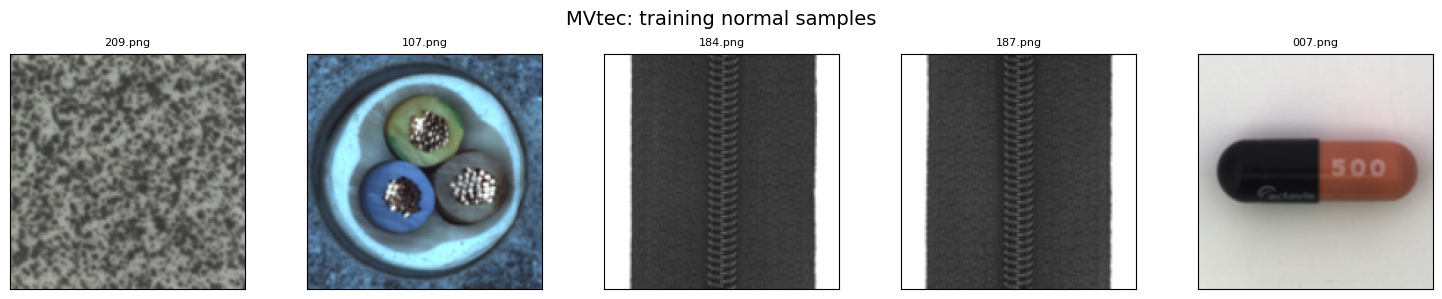

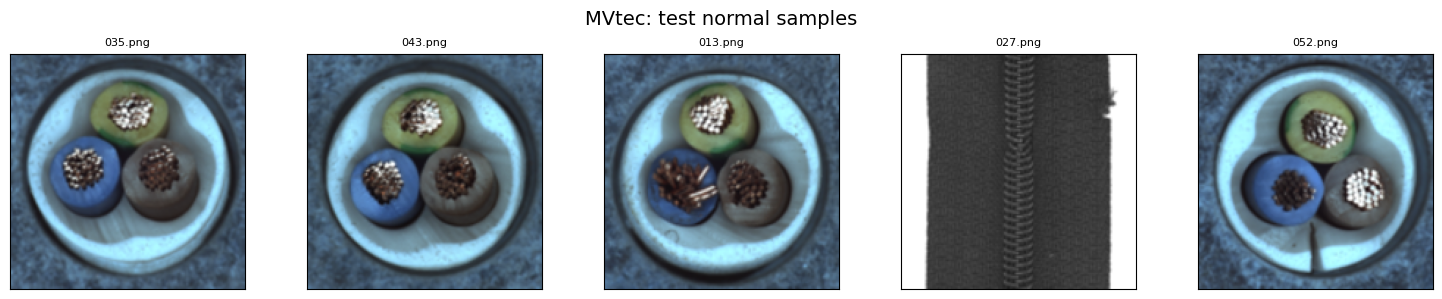

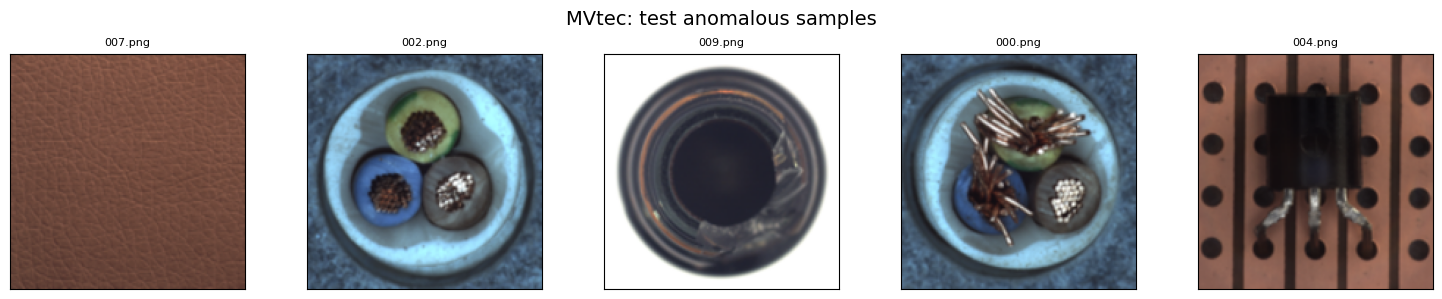

Robotics_Hazards


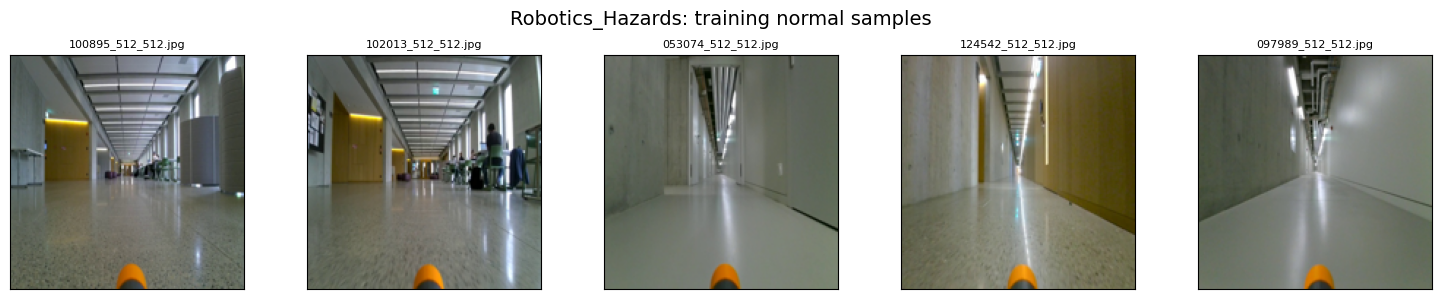

No samples found for dataset=Robotics_Hazards, split=test, label=normal


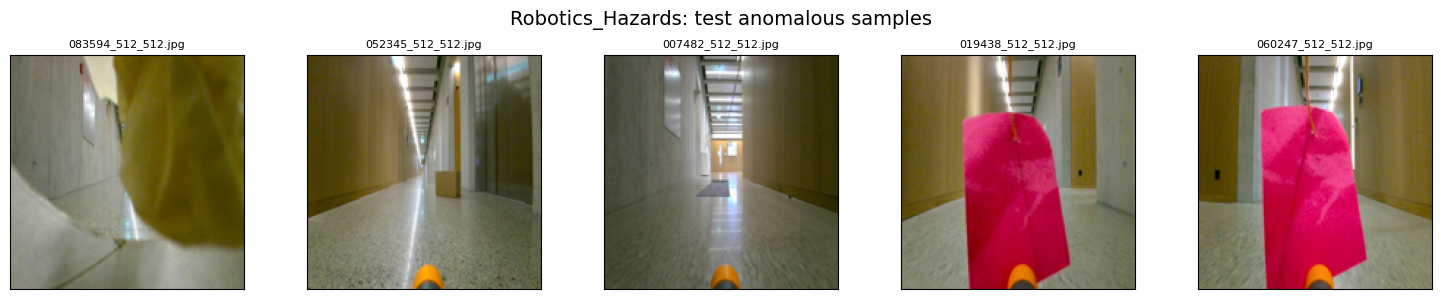

Cobots_Synthetic


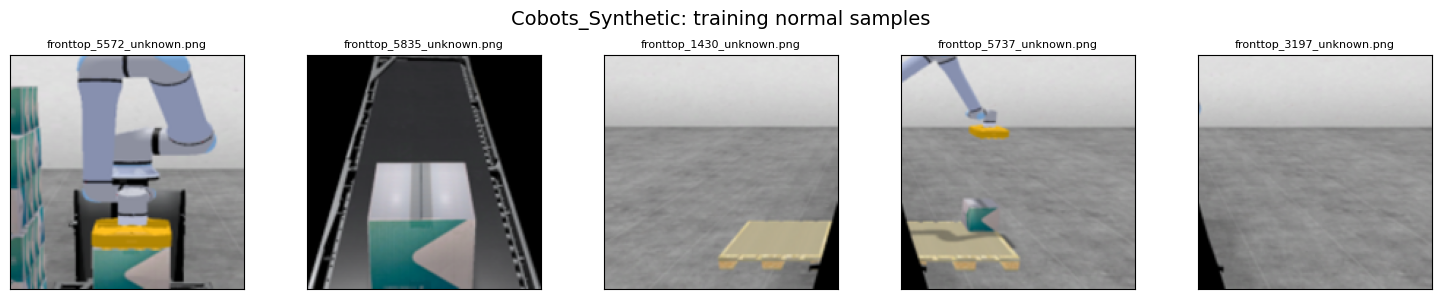

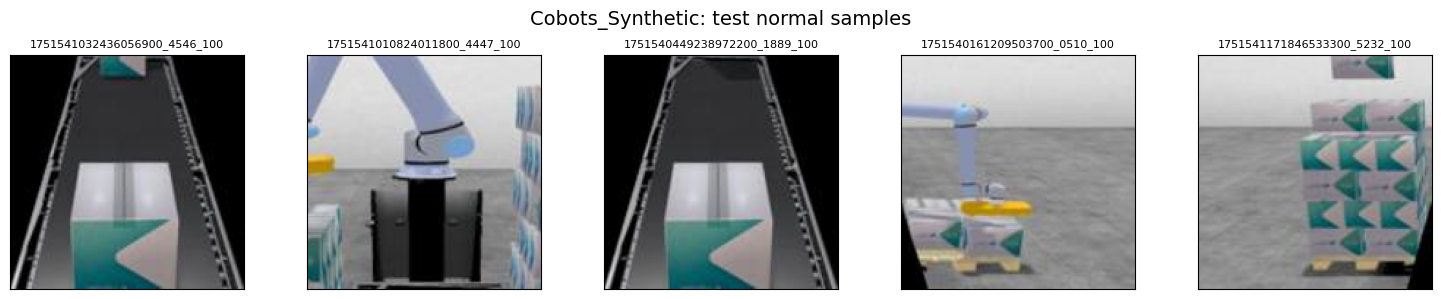

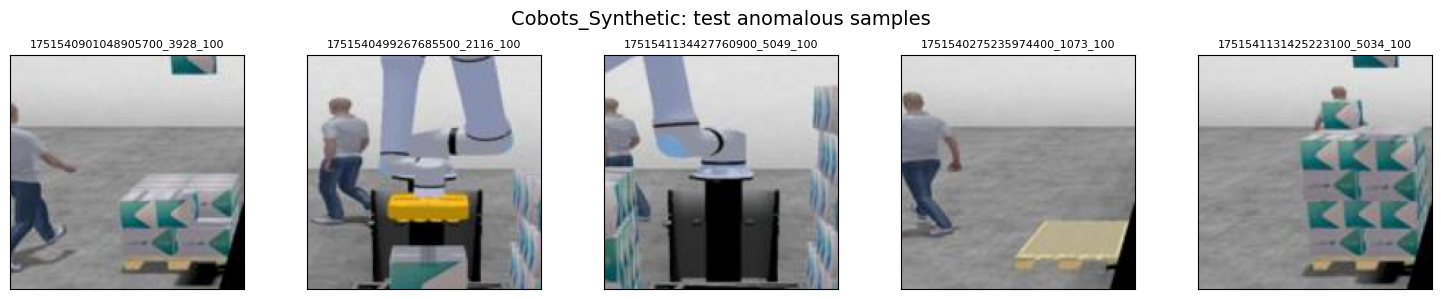

In [12]:
# ============================================================
# 9. Visualize samples
# ============================================================

def load_rgb(path, size=(160, 160)):
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = img.resize(size)
    return img


def show_samples(df, dataset_name, label=None, split=None, n=6, title=None):
    sub = df[df["dataset"] == dataset_name].copy()
    if label is not None:
        sub = sub[sub["label"] == label]
    if split is not None:
        sub = sub[sub["split"] == split]

    if sub.empty:
        print(f"No samples found for dataset={dataset_name}, split={split}, label={label}")
        return

    sample_paths = sub.sample(min(n, len(sub)), random_state=42)["path"].tolist()
    cols = len(sample_paths)
    fig, axes = plt.subplots(1, cols, figsize=(3 * cols, 3))
    if cols == 1:
        axes = [axes]

    for ax, p in zip(axes, sample_paths):
        img = load_rgb(p)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        rel = Path(p).name
        ax.set_title(rel[:28], fontsize=8)

    fig.suptitle(title or f"{dataset_name} | split={split} | label={label}", fontsize=14)
    plt.tight_layout()
    plt.show()

if scan_df.empty:
    print("No images available to visualize.")
else:
    for dataset_name in scan_df["dataset"].unique():
        print("=" * 80)
        print(dataset_name)
        print("=" * 80)
        show_samples(scan_df, dataset_name, label="normal", split="train", n=5, title=f"{dataset_name}: training normal samples")
        show_samples(scan_df, dataset_name, label="normal", split="test", n=5, title=f"{dataset_name}: test normal samples")
        show_samples(scan_df, dataset_name, label="anomaly", split="test", n=5, title=f"{dataset_name}: test anomalous samples")

## 10. Safety-area-level inspection

For `Robotics_Hazards` and `Distrimuse_UniGra`, this cell searches for the four safety areas in paths and reports counts.

In [10]:
# ============================================================
# 10. Safety area inspection
# ============================================================
SAFETY_AREAS = ["PLeft", "PRight", "RoboArm", "ConvBelt"]

def infer_safety_area(path):
    text = str(path).lower()
    for area in SAFETY_AREAS:
        if area.lower() in text:
            return area
    return "unknown"

if scan_df.empty:
    print("No images found.")
else:
    scan_df["safety_area"] = scan_df["path"].apply(infer_safety_area)
    display(scan_df.groupby(["dataset", "safety_area", "split", "label"]).size().reset_index(name="num_images"))

    for dataset_name in ["Robotics_Hazards", "Distrimuse_UniGra"]:
        if dataset_name not in scan_df["dataset"].unique():
            continue
        for area in SAFETY_AREAS:
            sub = scan_df[(scan_df["dataset"] == dataset_name) & (scan_df["safety_area"] == area)]
            if sub.empty:
                continue
            print(f"\n{dataset_name} - {area}: {len(sub):,} images")
            show_samples(sub, dataset_name, label="normal", split="train", n=4, title=f"{dataset_name} | {area} | train normal")
            show_samples(sub, dataset_name, label="anomaly", split="test", n=4, title=f"{dataset_name} | {area} | test anomaly")

,dataset,safety_area,split,label,num_images
0,Cobots_Synthetic,ConvBelt,test,normal,5864
1,Cobots_Synthetic,ConvBelt,train,normal,6008
2,Cobots_Synthetic,PLeft,test,anomaly,166
3,Cobots_Synthetic,PLeft,test,normal,5698
4,Cobots_Synthetic,PLeft,train,normal,6008
5,Cobots_Synthetic,PRight,test,anomaly,42
6,Cobots_Synthetic,PRight,test,normal,5822
7,Cobots_Synthetic,PRight,train,normal,6008
8,Cobots_Synthetic,RoboArm,test,anomaly,25
9,Cobots_Synthetic,RoboArm,test,normal,5839


## 11. Save dataset summary

This saves CSV summaries into `results/dataset_verification/`.

In [11]:
# ============================================================
# 11. Save summaries
# ============================================================
OUT_DIR = PROJECT_ROOT / "results" / "dataset_verification"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not scan_df.empty:
    scan_df.to_csv(OUT_DIR / "dataset_file_scan.csv", index=False)
    scan_df.groupby(["dataset", "split", "label"]).size().reset_index(name="num_images").to_csv(
        OUT_DIR / "dataset_split_label_summary.csv", index=False
    )
    datasets_df.to_csv(OUT_DIR / "dataset_paths_status.csv", index=False)
    print("Saved summaries to:", OUT_DIR)
else:
    print("Nothing to save because no dataset images were found.")

Saved summaries to: E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\results\dataset_verification


## 12. Notes for Windows symlinks

If a dataset is stored outside the repository, either put the absolute path in `configs/config.yaml`, or create a symlink inside `data/`.

PowerShell example:

```powershell
New-Item -ItemType SymbolicLink `
  -Path "data\Distrimuse_UniGra" `
  -Target "E:\Datasets\Distrimuse_UniGra"
```

CMD example:

```cmd
mklink /D data\Distrimuse_UniGra E:\Datasets\Distrimuse_UniGra
```